In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt; plt.style.use("dark_background")
import seaborn as sns
import sys; sys.path.append("/data/jerrylee/pjt/BIGFAM.v.0.1")
from BIGFAM import obj1, tools
from tqdm import tqdm

In [2]:
# ad-hoc functions
def simul_frreg(G, S, w, dor):
    """Make FR-reg coefficient.
    
    G : heritability
    S : variance component by shared env (d=1)
    w : decaying parameter for S
    dor : degree of relatedness
    """
    by_G = G * (1/2)**dor
    by_S = S * (1/w)**(dor-1)
    
    return by_G + by_S

# Step 1. prediction

In [5]:
df_frlog = pd.DataFrame(columns=[
    "G", "S", "w", "sig", "warning", "slope", "intercept"
])
se_frreg = 5e-3
df_res = pd.DataFrame(columns=[
    "G_true", "S_true", "w_true", "FRLogreg", "G", "S1", "w0"
])

G, S = 0.5, 0.1

# ws = [1.1, 1.5, 1.9, 2.1, 2.5, 2.9, 3.3, 3.7, 4.1, 4.5, 4.9] 
ws = [2.5]
for w in tqdm(ws):

    df_frreg = pd.DataFrame({
        "DOR": [1, 2, 3],
        "slope": [simul_frreg(G, S, w, d) for d in range(1, 4)],
        "se": se_frreg,
    })
    
    # generate 1000 resampled FR-reg coefficients 
    df_lmbds = obj1.resampleFrregCoefficients(df_frreg, n_resample=100)    
    df_frlogreg = obj1.familialRelationshipLogRegression(df_lmbds)
    
    frlogreg_sig = "None"
    if (np.percentile(df_frlogreg["slope"], 2.5) > 1):
        frlogreg_sig = "High"
    if (np.percentile(df_frlogreg["slope"], 97.5) < 1):
        frlogreg_sig = "Low"
        
        
    # prediction with grid search (WIDE)
    pred = obj1.prediction(df_lmbds, frlogreg_sig, print_prog=True)
                                
    df_res.loc[len(df_res)] = [G, S, w, frlogreg_sig, 
                               pred.median()["V(g)"], 
                               pred.median()["V(s)"], 
                               pred.median()["w"]]

  0%|          | 0/1 [00:00<?, ?it/s]

1..2..3..4..5..6..7..8..9..10..

  0%|          | 0/1 [04:27<?, ?it/s]


In [ ]:
# df_res.to_csv(
#     "/data/jerrylee/pjt/BIGFAM.v.0.1/data/simulation/pred/simulation.pred",
#     sep='\t',
#     index=False
# )

# Step 2. plot

In [14]:
df_res = pd.read_csv(
    "/data/jerrylee/pjt/BIGFAM.v.0.1/data/simulation/pred/simulation.pred",
    sep='\t'
)

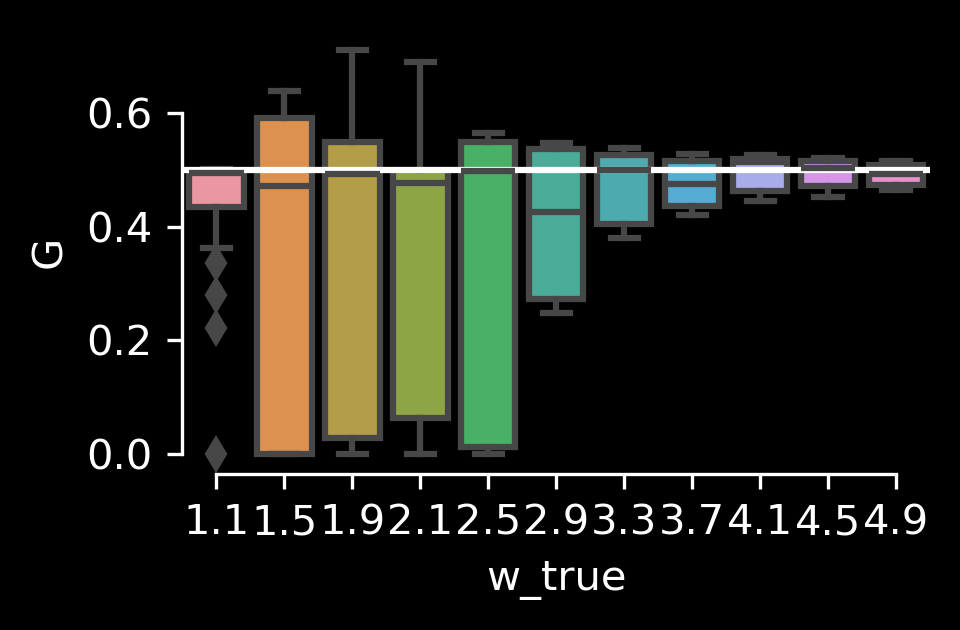

In [16]:
fig, ax = plt.subplots(1, 1, figsize=(3.3, 2.2), dpi=300)

sns.boxplot(data=df_res,
            x="w_true",
            y="G",)

# reference
plt.axhline(0.5)
ax.set_yticks([0, 0.2, 0.4, 0.6,])

sns.despine(offset=0.1, trim=True);
plt.tight_layout();

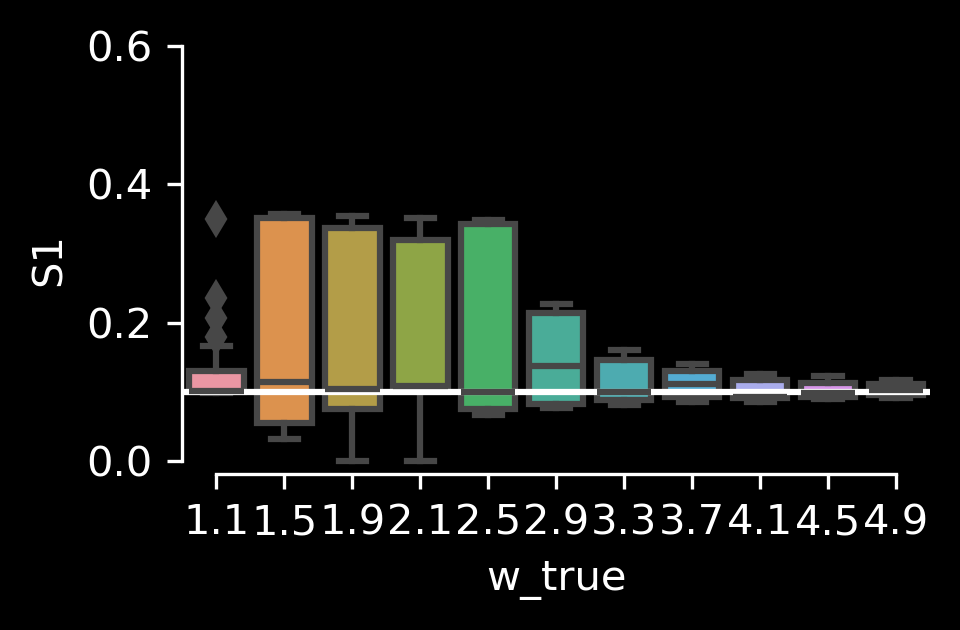

In [18]:
fig, ax = plt.subplots(1, 1, figsize=(3.3, 2.2), dpi=300)

sns.boxplot(data=df_res,
            x="w_true",
            y="S1",)

# reference
plt.axhline(0.1)
ax.set_yticks([0, 0.2, 0.4, 0.6,])

sns.despine(offset=0.1, trim=True);
plt.tight_layout();

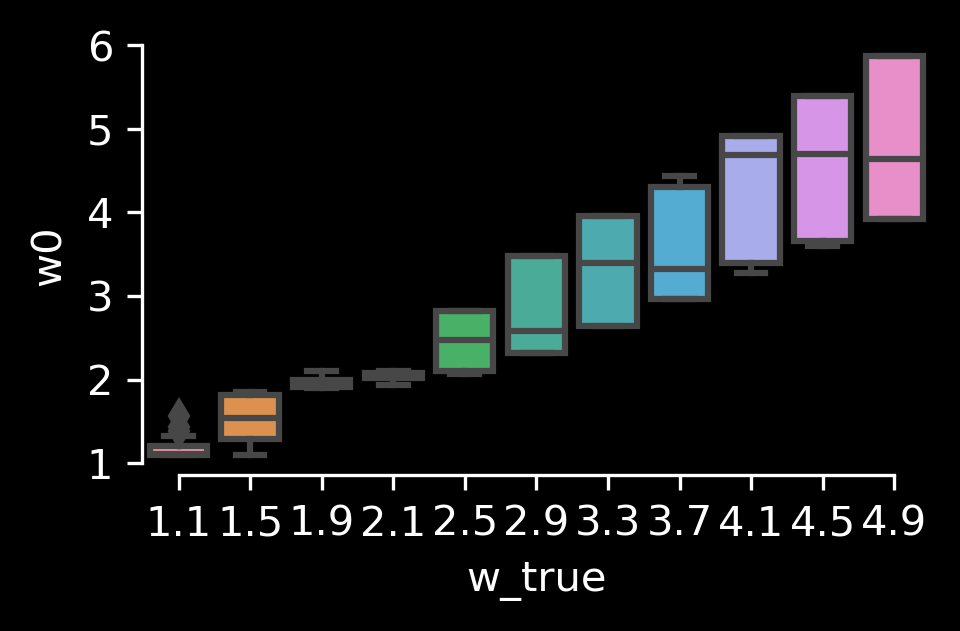

In [19]:
fig, ax = plt.subplots(1, 1, figsize=(3.3, 2.2), dpi=300)

sns.boxplot(data=df_res,
            x="w_true",
            y="w0",)

# reference
# plt.axhline(0.1)
# ax.set_yticks([0, 0.2, 0.4, 0.6,])
sns.despine(offset=0.1, trim=True);
plt.tight_layout();